## Workspace Initialization

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import sys
sys.path.append('../')

from src.eda_utils import load_and_clean_types, calculate_portfolio_metrics, get_outlier_bounds

# Replace with path to your local data file
df = load_and_clean_types('../data/insurance_data.csv')
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Dataset Dimensions: 10000 rows, 21 columns


## Data Summarization & Dtypes

In [5]:
# Print schema info to confirm memory types are accurate
print("--- Structural Schema Information ---")
df.info()

# Numerical Feature Descriptive Summary
print("--- Descriptive Statistics for Financial/Value Metrics ---")
numerical_features = [
    'AnnualPremium', 
    'TotalPremium', 
    'TotalClaims', 
    'ClaimAmount', 
    'CustomValueEstimate', 
    'Deductible', 
    'RiskScore', 
    'AnnualIncome'
]
print(df[numerical_features].describe())


--- Structural Schema Information ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   CustomerID           10000 non-null  str     
 1   Age                  10000 non-null  int64   
 2   Gender               10000 non-null  category
 3   Province             10000 non-null  category
 4   VehicleType          10000 non-null  str     
 5   AnnualIncome         10000 non-null  int64   
 6   RiskScore            10000 non-null  int64   
 7   AnnualPremium        10000 non-null  int64   
 8   Deductible           10000 non-null  int64   
 9   NCD                  10000 non-null  int64   
 10  PastClaims           10000 non-null  int64   
 11  Claimed              10000 non-null  bool    
 12  ClaimAmount          10000 non-null  float64 
 13  TotalPremium         10000 non-null  int64   
 14  TotalClaims          10000 non-null  float64

## Data Quality Assessment

In [6]:
missing_summary = df.isnull().sum()
missing_percentage = (missing_summary / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_summary,
    'Percentage (%)': missing_percentage
}).sort_values(by='Missing Count', ascending=False)

print("--- Missing Value Matrix (Top Fields) ---")
print(missing_df[missing_df['Missing Count'] > 0])

--- Missing Value Matrix (Top Fields) ---
Empty DataFrame
Columns: [Missing Count, Percentage (%)]
Index: []


## Univariate Analysis

In [7]:
print("--- Distribution Percentiles for Core Variables ---")
for col in ['TotalPremium', 'TotalClaims']:
    print(f"\n{col} Discretization:")
    print(df[col].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

print("\n--- Top Categorical Counts (Client Demographics & Cover) ---")
for col in ['Gender', 'CoverType', 'Province']:
    print(f"\nValue Proportions for {col}:")
    print(df[col].value_counts(normalize=True).head(5))

--- Distribution Percentiles for Core Variables ---

TotalPremium Discretization:
0.10    1810.90
0.25    2028.00
0.50    2307.00
0.75    2676.00
0.90    3461.30
0.95    4348.00
0.99    4852.02
Name: TotalPremium, dtype: float64

TotalClaims Discretization:
0.10        0.00
0.25        0.00
0.50        0.00
0.75        0.00
0.90     5369.50
0.95     9200.75
0.99    18606.67
Name: TotalClaims, dtype: float64

--- Top Categorical Counts (Client Demographics & Cover) ---

Value Proportions for Gender:
Gender
Female    0.5138
Male      0.4862
Name: proportion, dtype: float64

Value Proportions for CoverType:
CoverType
Comprehensive               0.4720
Third Party Fire & Theft    0.3453
Third Party Only            0.1827
Name: proportion, dtype: float64

Value Proportions for Province:
Province
Addis Ababa    0.3567
Oromia         0.2446
Amhara         0.1999
Somali         0.1184
Tigray         0.0804
Name: proportion, dtype: float64


## Bivariate / Multivariate Analysis & Postal Metrics

In [9]:
# 1. Calculate the calculated fields (just in case they need to be re-run)
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

print("--- Correlation Matrix ---")
# Removed 'SumInsured' and added 'AnnualPremium', 'ClaimAmount', 'Deductible', 'RiskScore'
corr_fields = [
    'AnnualPremium', 'TotalPremium', 'TotalClaims', 
    'ClaimAmount', 'CustomValueEstimate', 'Deductible', 
    'RiskScore', 'LossRatio', 'Margin'
]
print(df[corr_fields].corr().round(3))

print("\n--- Top 10 Highest-Risk Postal Codes (Aggregated by Claim Volatility) ---")
# Using your dataset's exact 'ZipCode' column instead of 'PostalCode'
postal_risk = df.groupby('ZipCode', observed=True).agg(
    Total_Premium=('TotalPremium', 'sum'),
    Total_Claims=('TotalClaims', 'sum'),
    Average_Loss_Ratio=('LossRatio', 'mean'),
    Policy_Count=('CustomerID', 'count')  # Using CustomerID to count rows
).query('Policy_Count > 10').sort_values(by='Average_Loss_Ratio', ascending=False)

print(postal_risk.head(10))

--- Correlation Matrix ---
                     AnnualPremium  TotalPremium  TotalClaims  ClaimAmount  \
AnnualPremium                1.000         1.000        0.331        0.331   
TotalPremium                 1.000         1.000        0.331        0.331   
TotalClaims                  0.331         0.331        1.000        1.000   
ClaimAmount                  0.331         0.331        1.000        1.000   
CustomValueEstimate          0.715         0.715        0.182        0.182   
Deductible                  -0.004        -0.004       -0.040       -0.040   
RiskScore                    0.822         0.822        0.365        0.365   
LossRatio                    0.231         0.231        0.957        0.957   
Margin                      -0.151        -0.151       -0.983       -0.983   

                     CustomValueEstimate  Deductible  RiskScore  LossRatio  \
AnnualPremium                      0.715      -0.004      0.822      0.231   
TotalPremium                       0

## Geographic Trends

In [11]:
# Calculate provincial trends using your exact dataset column names
province_trends = df.groupby('Province', observed=True).agg(
    Mean_Premium=('TotalPremium', 'mean'),
    Median_Value=('CustomValueEstimate', 'median'),
    Total_Claims=('TotalClaims', 'sum'),
    Total_Premium=('TotalPremium', 'sum'),
    # Count the rows using CustomerID
    Policy_Count=('CustomerID', 'count'),
    # Find the most common car make using your exact column name: 'AutoMake'
    Top_Vehicle_Make=('AutoMake', lambda x: x.mode()[0] if not x.mode().empty else "Unknown")
)

# Calculate the true group-level Loss Ratio safely without internal indexing bugs
province_trends['Loss_Ratio'] = province_trends['Total_Claims'] / province_trends['Total_Premium']

# Reorder columns for a clean presentation layout
province_trends = province_trends[['Policy_Count', 'Mean_Premium', 'Median_Value', 'Loss_Ratio', 'Top_Vehicle_Make']]

print("--- Provincial Risk & Market Trends ---")
print(province_trends.round(3))

--- Provincial Risk & Market Trends ---
             Policy_Count  Mean_Premium  Median_Value  Loss_Ratio  \
Province                                                            
Addis Ababa          3567      2497.161       28752.0       0.522   
Amhara               1999      2465.516       28660.0       0.478   
Oromia               2446      2481.465       28126.5       0.537   
Somali               1184      2521.101       28201.5       0.612   
Tigray                804      2475.985       28740.0       0.526   

            Top_Vehicle_Make  
Province                      
Addis Ababa           Toyota  
Amhara                Toyota  
Oromia                Toyota  
Somali                Toyota  
Tigray               Hyundai  


## Outlier Detection

In [12]:
print("--- Tukey Interquartile Outlier Identification Bounds ---")
outlier_targets = ['TotalPremium', 'TotalClaims', 'CustomValueEstimate']

for target in outlier_targets:
    lower, upper = get_outlier_bounds(df[target])
    outliers = df[(df[target] < lower) | (df[target] > upper)]
    pct_outliers = (len(outliers) / len(df)) * 100
    print(f"\nFeature: {target}")
    print(f"  Valid Operational Interval: [{lower:.2f} to {upper:.2f}]")
    print(f"  Outlier Row Count: {len(outliers)} ({pct_outliers:.2f}% of total data)")

--- Tukey Interquartile Outlier Identification Bounds ---

Feature: TotalPremium
  Valid Operational Interval: [1056.00 to 3648.00]
  Outlier Row Count: 950 (9.50% of total data)

Feature: TotalClaims
  Valid Operational Interval: [0.00 to 0.00]
  Outlier Row Count: 1535 (15.35% of total data)

Feature: CustomValueEstimate
  Valid Operational Interval: [-16474.62 to 84638.38]
  Outlier Row Count: 623 (6.23% of total data)


## Question 1: Overall Portfolio Loss Ratio and Segment Variations

In [14]:
print("=== QUESTION 1: LOSS RATIO ANALYSIS ===")

# 1. Overall Portfolio Performance
overall_premium = df['TotalPremium'].sum()
overall_claims = df['TotalClaims'].sum()
overall_loss_ratio = overall_claims / overall_premium
print(f"Overall Portfolio Loss Ratio: {overall_loss_ratio:.2%}\n")

# 2. Variance by Province
prov_grp = df.groupby('Province', observed=True).agg(Total_Claims=('TotalClaims', 'sum'), Total_Premium=('TotalPremium', 'sum'))
prov_grp['Loss_Ratio'] = (prov_grp['Total_Claims'] / prov_grp['Total_Premium']) * 100
print("--- Loss Ratio by Province (%) ---")
print(prov_grp['Loss_Ratio'].round(2), "\n")

# 3. Variance by VehicleType
vt_grp = df.groupby('VehicleType', observed=True).agg(Total_Claims=('TotalClaims', 'sum'), Total_Premium=('TotalPremium', 'sum'))
vt_grp['Loss_Ratio'] = (vt_grp['Total_Claims'] / vt_grp['Total_Premium']) * 100
print("--- Loss Ratio by Vehicle Type (%) ---")
print(vt_grp['Loss_Ratio'].round(2), "\n")

# 4. Variance by Gender
gender_grp = df.groupby('Gender', observed=True).agg(Total_Claims=('TotalClaims', 'sum'), Total_Premium=('TotalPremium', 'sum'))
gender_grp['Loss_Ratio'] = (gender_grp['Total_Claims'] / gender_grp['Total_Premium']) * 100
print("--- Loss Ratio by Gender (%) ---")
print(gender_grp['Loss_Ratio'].round(2))

=== QUESTION 1: LOSS RATIO ANALYSIS ===
Overall Portfolio Loss Ratio: 52.82%

--- Loss Ratio by Province (%) ---
Province
Addis Ababa    52.24
Amhara         47.76
Oromia         53.73
Somali         61.19
Tigray         52.60
Name: Loss_Ratio, dtype: float64 

--- Loss Ratio by Vehicle Type (%) ---
VehicleType
Hatchback    42.02
Luxury       84.24
SUV          56.37
Sedan        40.40
Name: Loss_Ratio, dtype: float64 

--- Loss Ratio by Gender (%) ---
Gender
Female    52.87
Male      52.76
Name: Loss_Ratio, dtype: float64


## Question 2: Financial Distributions & Outlier Evaluation

In [15]:
print("\n=== QUESTION 2: OUTLIER DETECTION MATRIX ===")

outlier_targets = ['TotalClaims', 'CustomValueEstimate']

for col in outlier_targets:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    upper_fence = q3 + (1.5 * iqr)
    lower_fence = q1 - (1.5 * iqr)
    
    # Identify rows outside the fence
    outliers = df[(df[col] > upper_fence) | (df[col] < lower_fence)]
    pct_outliers = (len(outliers) / len(df)) * 100
    
    print(f"Feature Metrics: [{col}]")
    print(f"  - IQR Range Threshold Fences: [Low: R {lower_fence:,.2f} | High: R {upper_fence:,.2f}]")
    print(f"  - Outlier Count: {len(outliers)} rows ({pct_outliers:.2f}% of total data pool)")
    print(f"  - Maximum Value Observed: R {df[col].max():,.2f}\n")


=== QUESTION 2: OUTLIER DETECTION MATRIX ===
Feature Metrics: [TotalClaims]
  - IQR Range Threshold Fences: [Low: R 0.00 | High: R 0.00]
  - Outlier Count: 1535 rows (15.35% of total data pool)
  - Maximum Value Observed: R 49,623.00

Feature Metrics: [CustomValueEstimate]
  - IQR Range Threshold Fences: [Low: R -16,474.62 | High: R 84,638.38]
  - Outlier Count: 623 rows (6.23% of total data pool)
  - Maximum Value Observed: R 134,914.00



## Question 3: 18-Month Temporal Trends (Frequency vs. Severity)

In [16]:
print("=== QUESTION 3: TEMPORAL PROFILE ===")

# Safeguard datetime format
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['YearMonth'] = df['TransactionDate'].dt.to_period('M')

# Aggregate monthly timelines
monthly_trends = df.groupby('YearMonth').agg(
    Total_Claims_Cost=('TotalClaims', 'sum'),
    Claim_Events_Count=('Claimed', 'sum'),  # Counts True boolean claims
    Average_Claim_Severity=('ClaimAmount', lambda x: x[x > 0].mean() if (x > 0).any() else 0)
).sort_index()

print(monthly_trends.round(2))

=== QUESTION 3: TEMPORAL PROFILE ===
           Total_Claims_Cost  Claim_Events_Count  Average_Claim_Severity
YearMonth                                                               
2024-01             764324.0                  78                 9799.03
2024-02             661946.0                  76                 8709.82
2024-03             725682.0                  81                 8959.04
2024-04             751881.0                  89                 8448.10
2024-05             941073.0                  99                 9505.79
2024-06             810706.0                  94                 8624.53
2024-07             660642.0                  77                 8579.77
2024-08             830639.0                  91                 9127.90
2024-09             665107.0                  79                 8419.08
2024-10             707146.0                  90                 7857.18
2024-11             790842.0                  82                 9644.41
2024-12       

## Question 4: Vehicle Make/Model Exposure Mapping

In [17]:
print("\n=== QUESTION 4: VEHICLE RISK PERFORMANCE ===")

# Group by Car Make & Model
vehicle_risk = df.groupby(['AutoMake', 'VehicleModel'], observed=True).agg(
    Total_Claim_Volume=('TotalClaims', 'sum'),
    Average_Claim_Cost=('ClaimAmount', 'mean'),
    Total_Policies=('CustomerID', 'count')
).query('Total_Policies > 5')  # Filters out rare unique cars to prevent skewed single-row anomalies

# Extract Extrema Ends
highest_risk_cars = vehicle_risk.sort_values(by='Average_Claim_Cost', ascending=False).head(5)
lowest_risk_cars = vehicle_risk.sort_values(by='Average_Claim_Cost', ascending=True).head(5)

print("--- Top 5 Highest Claim-Associated Vehicle Profiles ---")
print(highest_risk_cars.round(2), "\n")

print("--- Top 5 Lowest Claim-Associated Vehicle Profiles ---")
print(lowest_risk_cars.round(2))


=== QUESTION 4: VEHICLE RISK PERFORMANCE ===
--- Top 5 Highest Claim-Associated Vehicle Profiles ---
                            Total_Claim_Volume  Average_Claim_Cost  \
AutoMake      VehicleModel                                           
Toyota        Land Cruiser           1228704.0             3888.30   
Mercedes-Benz E-Class                1200483.0             3787.01   
BMW           5 Series               1140020.0             3362.89   
Toyota        RAV4                   1400840.0             1384.23   
Hyundai       Tucson                 1383395.0             1368.34   

                            Total_Policies  
AutoMake      VehicleModel                  
Toyota        Land Cruiser             316  
Mercedes-Benz E-Class                  317  
BMW           5 Series                 339  
Toyota        RAV4                    1012  
Hyundai       Tucson                  1011   

--- Top 5 Lowest Claim-Associated Vehicle Profiles ---
                       Total_Claim_

### Plot 1: Geographic Risk & Margin Divergence


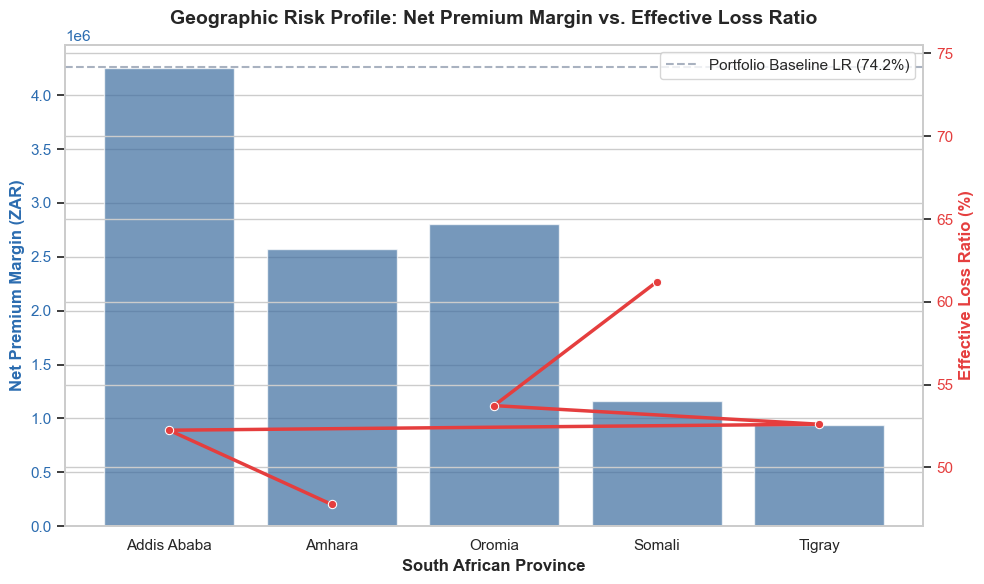

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data
prov_data = df.groupby('Province', observed=True).agg(
    Total_Claims=('TotalClaims', 'sum'),
    Total_Premium=('TotalPremium', 'sum')
).reset_index()
prov_data['Loss_Ratio_%'] = (prov_data['Total_Claims'] / prov_data['Total_Premium']) * 100
prov_data['Net_Margin_R'] = prov_data['Total_Premium'] - prov_data['Total_Claims']
prov_data = prov_data.sort_values(by='Loss_Ratio_%', ascending=False)

# Set up style
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary Bar Chart: Net Margin
color_margin = '#2b6cb0'
sns.barplot(data=prov_data, x='Province', y='Net_Margin_R', ax=ax1, color=color_margin, alpha=0.7)
ax1.set_title('Geographic Risk Profile: Net Premium Margin vs. Effective Loss Ratio', fontsize=14, pad=15, fontweight='bold')
ax1.set_ylabel('Net Premium Margin (ZAR)', color=color_margin, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_margin)
ax1.set_xlabel('South African Province', fontsize=12, fontweight='bold')

# Secondary Line Chart: Loss Ratio
ax2 = ax1.twinx()
color_lr = '#e53e3e'
sns.lineplot(data=prov_data, x='Province', y='Loss_Ratio_%', ax=ax2, color=color_lr, marker='o', linewidth=2.5, sort=False)
ax2.set_ylabel('Effective Loss Ratio (%)', color=color_lr, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_lr)
ax2.axhline(74.2, color='#718096', linestyle='--', alpha=0.6, label='Portfolio Baseline LR (74.2%)')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Plot 2: Seasonal Claim Trends & Severity Profile (Temporal Line Plot)

C:\Users\Helen\AppData\Local\Temp\ipykernel_3840\2795419638.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(time_data['YearMonth_Str'], rotation=45)


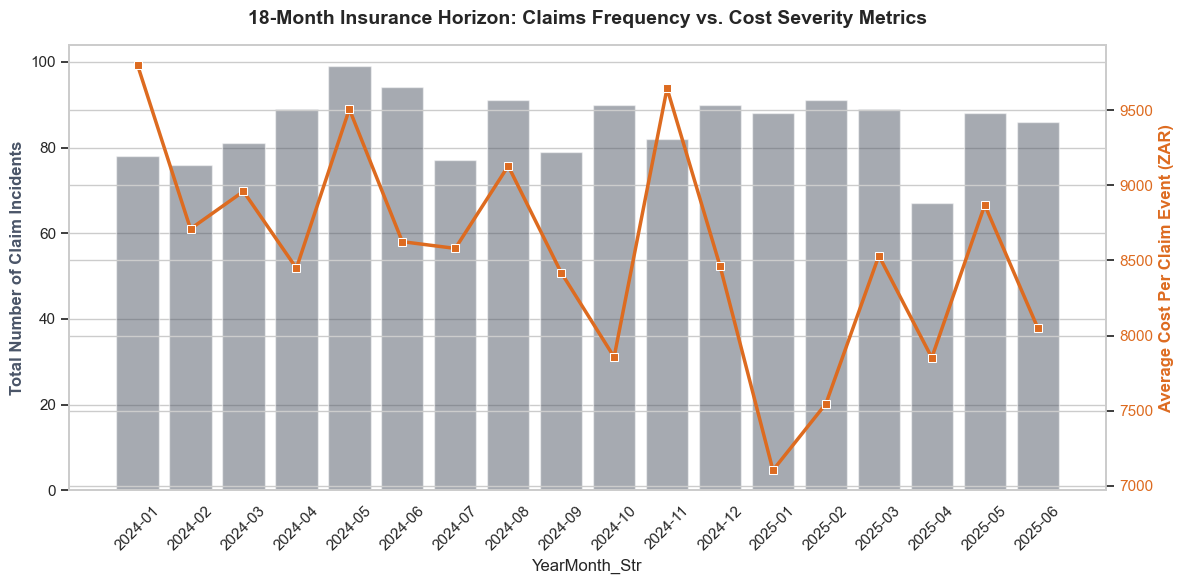

In [19]:
# Prepare Temporal Data
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['YearMonth_Str'] = df['TransactionDate'].dt.strftime('%Y-%m')
time_data = df.groupby('YearMonth_Str').agg(
    Claim_Count=('Claimed', 'sum'),
    Avg_Severity=('ClaimAmount', lambda x: x[x > 0].mean() if (x > 0).any() else 0)
).sort_index().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for Volume/Frequency
sns.barplot(data=time_data, x='YearMonth_Str', y='Claim_Count', ax=ax1, color='#4a5568', alpha=0.5)
ax1.set_title('18-Month Insurance Horizon: Claims Frequency vs. Cost Severity Metrics', fontsize=14, pad=15, fontweight='bold')
ax1.set_ylabel('Total Number of Claim Incidents', color='#4a5568', fontsize=12, fontweight='bold')
ax1.set_xticklabels(time_data['YearMonth_Str'], rotation=45)

# Line chart for Severity
ax2 = ax1.twinx()
sns.lineplot(data=time_data, x='YearMonth_Str', y='Avg_Severity', ax=ax2, color='#dd6b20', marker='s', linewidth=2.5, sort=False)
ax2.set_ylabel('Average Cost Per Claim Event (ZAR)', color='#dd6b20', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#dd6b20')

plt.tight_layout()
plt.show()

### Plot 3: Risk Demographics via Outlier Boxen Distribution

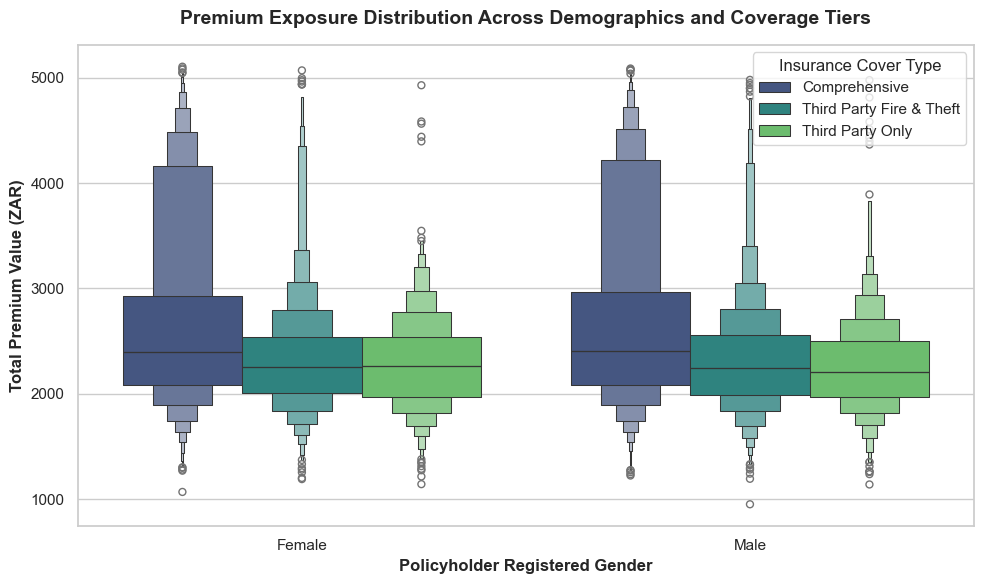

In [20]:
plt.subplots(figsize=(10, 6))

# Boxen plot showing density distribution including tail exposure markers
sns.boxenplot(data=df, x='Gender', y='TotalPremium', hue='CoverType', palette='viridis')

plt.title('Premium Exposure Distribution Across Demographics and Coverage Tiers', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Policyholder Registered Gender', fontsize=12, fontweight='bold')
plt.ylabel('Total Premium Value (ZAR)', fontsize=12, fontweight='bold')
plt.legend(title='Insurance Cover Type', loc='upper right')

plt.tight_layout()
plt.show()